# Deutsch-Jozsa
One query decides whether an oracle $f:\{0,1\}^n\!\to\!\{0,1\}$ is **constant** or **balanced**.
Measure the $n$-qubit input register: all-zeros $\Rightarrow$ constant, anything else $\Rightarrow$ balanced.
Run twice — an ideal simulator and a noisy one carrying a real IBM device's noise model (offline) — to see how hardware error degrades the result.

In [1]:
# Oracle: 'constant' does nothing to the target; 'balanced' CXs every input into it
from qiskit import QuantumCircuit

def dj_oracle(n: int, kind: str) -> QuantumCircuit:
    oracle = QuantumCircuit(n + 1)
    if kind == "balanced":
        for q in range(n):
            oracle.cx(q, n)
    elif kind != "constant":
        raise ValueError("kind must be 'constant' or 'balanced'")
    return oracle

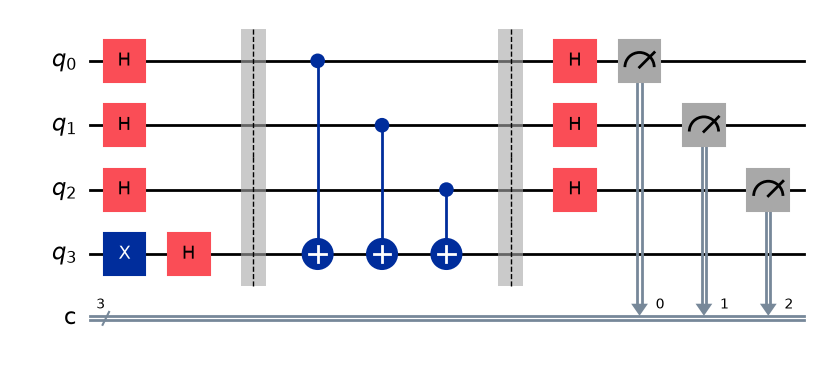

In [2]:
# Assemble the full Deutsch-Jozsa circuit and draw it
n = 3
kind = "balanced"   # try "constant" too

qc = QuantumCircuit(n + 1, n)
qc.x(n)                       # target starts in |1>
qc.h(range(n + 1))            # superposition + |-> on target
qc.barrier()
qc.compose(dj_oracle(n, kind), inplace=True)
qc.barrier()
qc.h(range(n))               # interference on the input register
qc.measure(range(n), range(n))

qc.draw("mpl")

In [3]:
# Run on an ideal simulator and a noisy one (FakeSherbrooke = real IBM device noise model, offline)
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

ideal = AerSimulator()
noisy = AerSimulator.from_backend(FakeSherbrooke())

counts_ideal = ideal.run(transpile(qc, ideal), shots=1024).result().get_counts()
counts_noisy = noisy.run(transpile(qc, noisy, optimization_level=3), shots=1024).result().get_counts()

ideal peak : 111
noisy peak : 111


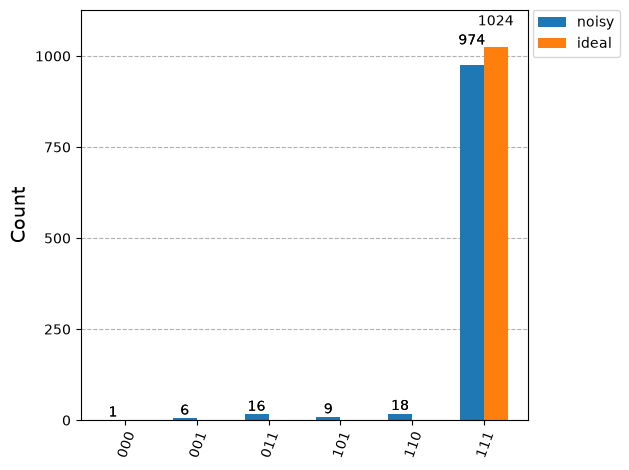

In [4]:
# All-zeros => constant, anything else => balanced. Noisy adds a spread of wrong answers.
from qiskit.visualization import plot_histogram

print("ideal peak :", max(counts_ideal, key=counts_ideal.get))
print("noisy peak :", max(counts_noisy, key=counts_noisy.get))
plot_histogram([counts_noisy, counts_ideal], legend=["noisy", "ideal"])